# Predicting NBA Rookie Performance from Pre-NBA Statistics

**Research question:** How well do a player's latest available pre-NBA season statistics predict rookie-season Player Efficiency Rating (PER) and Win Shares (WS)?

**Project type:** Regression  
**Population:** Players drafted from 2018 through 2023  
**Unit of analysis:** One drafted player, matched by Basketball-Reference player ID  
**Models:** Multiple linear regression and degree-two polynomial regression, compared with a training-mean baseline

My project studies historical relationships; it is not a draft decision tool.

## 1. Problem definition

NBA teams, scouts, and fans want to understand which statistics are associated with a player's predicted performance in the professional level, basing off of their pre-NBA stats from their previous organization they played for. This project asks whether points, rebounds, assists, turnovers, field-goal percentage, and age from a player's latest available season can predict two continuous rookie outcomes: PER and WS(win shares).

A prediction could help summarize a prospect's statistical profile, but it cannot capture every factor that shapes a career. Competition level, role, team situation, health, skills not represented in box scores, and playing time all affect outcomes. The models provide a limited baseline for comparison rather than a player evaluation or causal explanation.

## 2. Background and context

Research has examined whether college production relates to later professional performance. Coates and Oguntimein (2010) studied whether college productivity predicts professional productivity and career length. They report that some college productivity measures were associated with draft position, and those relationships differed by conference context. Moxley and Towne (2015) emphasize that NBA success involves both stability and potential, which cautions against treating one season's box-score line as a complete measure of future performance.

This project measures rookie performance with PER and WS. Basketball-Reference describes Win Shares as an estimate of the wins a player contributed, connected to team success. Both targets have limitations: PER is a summary efficiency rating, and total WS also reflects playing time and team context. Models can find associations in these data, but they cannot establish that a college statistic causes NBA success. References appear at the end.

## 3. Variables and operational definitions

| Concept | Variable | Operational definition |
|---|---|---|
| Rookie performance | PER | PER from the player's first NBA season in the outcomes file |
| Rookie team value | WS | Total Win Shares from that NBA rookie season |
| Scoring | PTS_per_game | Estimated points per game in the latest available pre-NBA season |
| Rebounding | REB_per_game | Estimated rebounds per game in that season |
| Playmaking | AST_per_game | Estimated assists per game in that season |
| Ball security | TOV_per_game | Estimated turnovers per game in that season |
| Shooting efficiency | FG_pct | Field-goal percentage stored as a fraction (0.500 = 50.0%) |
| Age / experience proxy | Age | Age calculated on January 31 of the season-ending year; it is a proxy, not age at draft or college class |

The model uses all six numeric pre-NBA predictors. College class and field-goal attempts per game are not included because they are unavailable in the supplied files. Per-game box-score values were derived from per-40 rates and total minutes in the source dataset.

## 4. Data collection and coverage

The supplied CSVs cover 356 drafted players across six draft classes. The rookie outcomes file has PER and WS for 336 players. The pre-NBA file has a season record for 246 players. Requiring all six predictors and both outcomes leaves 240 players for regression.

The pre-NBA CSV comes from a compiled draft-prospect dataset whose README credits RealGM, Basketball-Reference, Bart Torvik, Hoop-Math, and 247Sports. It is not a uniform NCAA-only table, so this project calls the feature period the **latest available pre-NBA season**. Many international or other non-college seasons are blank in the supplied data. Those players remain in the source CSV but cannot enter complete-case models.

The NBA outcome file links each record to the draft page and advanced-stat page. The files are joined by player ID, not names alone.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from nba_rookie_analysis import DATA_DIR, OUTPUT_DIR, FEATURES, TARGETS, load_data

merged, complete = load_data()
coverage = pd.DataFrame({
    "Measure": [
        "Drafted players in both source files",
        "Players with a pre-NBA season record",
        "Players with both rookie outcomes",
        "Complete cases used in both models",
        "Training players (draft years 2018-2021)",
        "Holdout players (draft years 2022-2023)",
    ],
    "Count": [
        len(merged),
        int(merged["PreNBASeason"].notna().sum()),
        int(merged[TARGETS].notna().all(axis=1).sum()),
        len(complete),
        int(complete["DraftYear"].between(2018, 2021).sum()),
        int(complete["DraftYear"].between(2022, 2023).sum()),
    ],
})
display(coverage)

,Measure,Count
0,Drafted players in both source files,356
1,Players with a pre-NBA season record,246
2,Players with both rookie outcomes,336
3,Complete cases used in both models,240
4,Training players (draft years 2018-2021),166
5,Holdout players (draft years 2022-2023),74


## 5. Data understanding and preparation

The models require complete predictor and outcome values. Blank pre-NBA fields are not replaced with zero: zero would incorrectly mean a player had no recorded points, rebounds, or other performance. The complete-case rule leaves 240 players.

The holdout consists of the 2022 and 2023 draft classes. Models train on the 2018-2021 classes and predict the later two classes. This chronological split better represents predicting future draft cohorts than randomly mixing players from every year.

In [2]:
display(complete[FEATURES + TARGETS].describe().T.round(3))
print("Draft-year sample sizes:")
display(complete.groupby("DraftYear").size().rename("Complete players").to_frame())
print("Feature correlations with the outcomes (descriptive, not causal):")
display(complete[FEATURES + TARGETS].corr(numeric_only=True)[TARGETS].round(3))

,count,mean,std,min,25%,50%,75%,max
PTS_per_game,240.0,15.094,4.025,3.291,12.540,15.188,17.674,27.351
REB_per_game,240.0,5.906,2.154,1.675,4.240,5.504,7.428,11.625
AST_per_game,240.0,2.603,1.633,0.222,1.443,2.175,3.365,10.058
TOV_per_game,240.0,2.084,0.713,0.659,1.570,2.058,2.538,5.222
FG_pct,240.0,0.485,0.073,0.322,0.438,0.474,0.514,0.769
Age,240.0,19.900,1.350,18.000,19.000,20.000,21.000,23.000
PER,240.0,10.618,5.301,-20.000,8.400,10.600,13.000,26.400
WS,240.0,0.915,1.480,-1.600,0.000,0.300,1.425,8.900


Draft-year sample sizes:


,Complete players
DraftYear,
2018,38
2019,46
2020,42
2021,40
2022,37
2023,37


Feature correlations with the outcomes (descriptive, not causal):


,PER,WS
PTS_per_game,0.051,0.081
REB_per_game,0.275,0.231
AST_per_game,-0.100,0.020
TOV_per_game,-0.085,-0.099
FG_pct,0.366,0.367
Age,-0.068,-0.023
PER,1.000,0.512
WS,0.512,1.000


## 6. Visualization 1: pre-NBA scoring and rookie outcomes

These plots show points per game against rookie PER and total rookie WS. Each point is one player, colored by draft year. The line is a descriptive linear trend across all complete cases, not a holdout prediction or causal estimate. Total WS also depends on playing time.

## 7. Model design

The baseline predicts the training-class mean for every holdout player. Multiple linear regression estimates a straight-line relationship between the six standardized predictors and each outcome. Polynomial regression expands the predictors to include squared and pairwise interaction terms, then applies Ridge regularization (alpha = 10) to limit overfitting. This setting is fixed for this project, not optimized through a separate tuning search.

Both models predict PER and WS separately. MAE and RMSE measure error in the outcome's units; lower values are better. R-squared measures test-set variation explained relative to predicting the test mean; higher is better, and negative values indicate performance worse than that reference.

In [3]:
from nba_rookie_analysis import fit_and_evaluate, make_visualizations

metrics, predictions, fitted_models, train, test = fit_and_evaluate(complete)
make_visualizations(complete, predictions, metrics)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
metrics.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
predictions.to_csv(OUTPUT_DIR / "holdout_predictions.csv", index=False)
display(metrics.round(3))
print(f"Training sample: {len(train)} players; chronological holdout: {len(test)} players.")

,Target,Model,Train_n,Test_n,MAE,RMSE,R2
0,PER,Mean baseline,166,74,3.680,4.948,-0.007
1,PER,Linear regression,166,74,3.320,4.391,0.207
2,PER,Polynomial regression (degree 2),166,74,3.299,4.332,0.229
3,WS,Mean baseline,166,74,1.231,1.866,-0.022
4,WS,Linear regression,166,74,1.066,1.617,0.233
5,WS,Polynomial regression (degree 2),166,74,1.063,1.613,0.237


Training sample: 166 players; chronological holdout: 74 players.


## 8. Visualization 2: holdout predictions

This chart checks predictions for the 74 players from the 2022 and 2023 draft classes. The models were trained on 166 players from 2018–2021. The horizontal axis is the actual rookie outcome; the vertical axis is the model’s prediction. The dashed diagonal represents a perfect prediction. Dots nearer that line are more accurate.

The first column is the mean baseline: it predicts about the same value for every player, so its dots form a horizontal band. The other columns show linear regression and polynomial regression. Their dots follow the diagonal more closely, meaning those models did better than simply predicting the training average. Still, many points are far from the line. For example, the WS panels show some players with high actual WS whose predictions are much lower. The models tend to predict closer to the middle of the group and miss some unusually high or low outcomes.

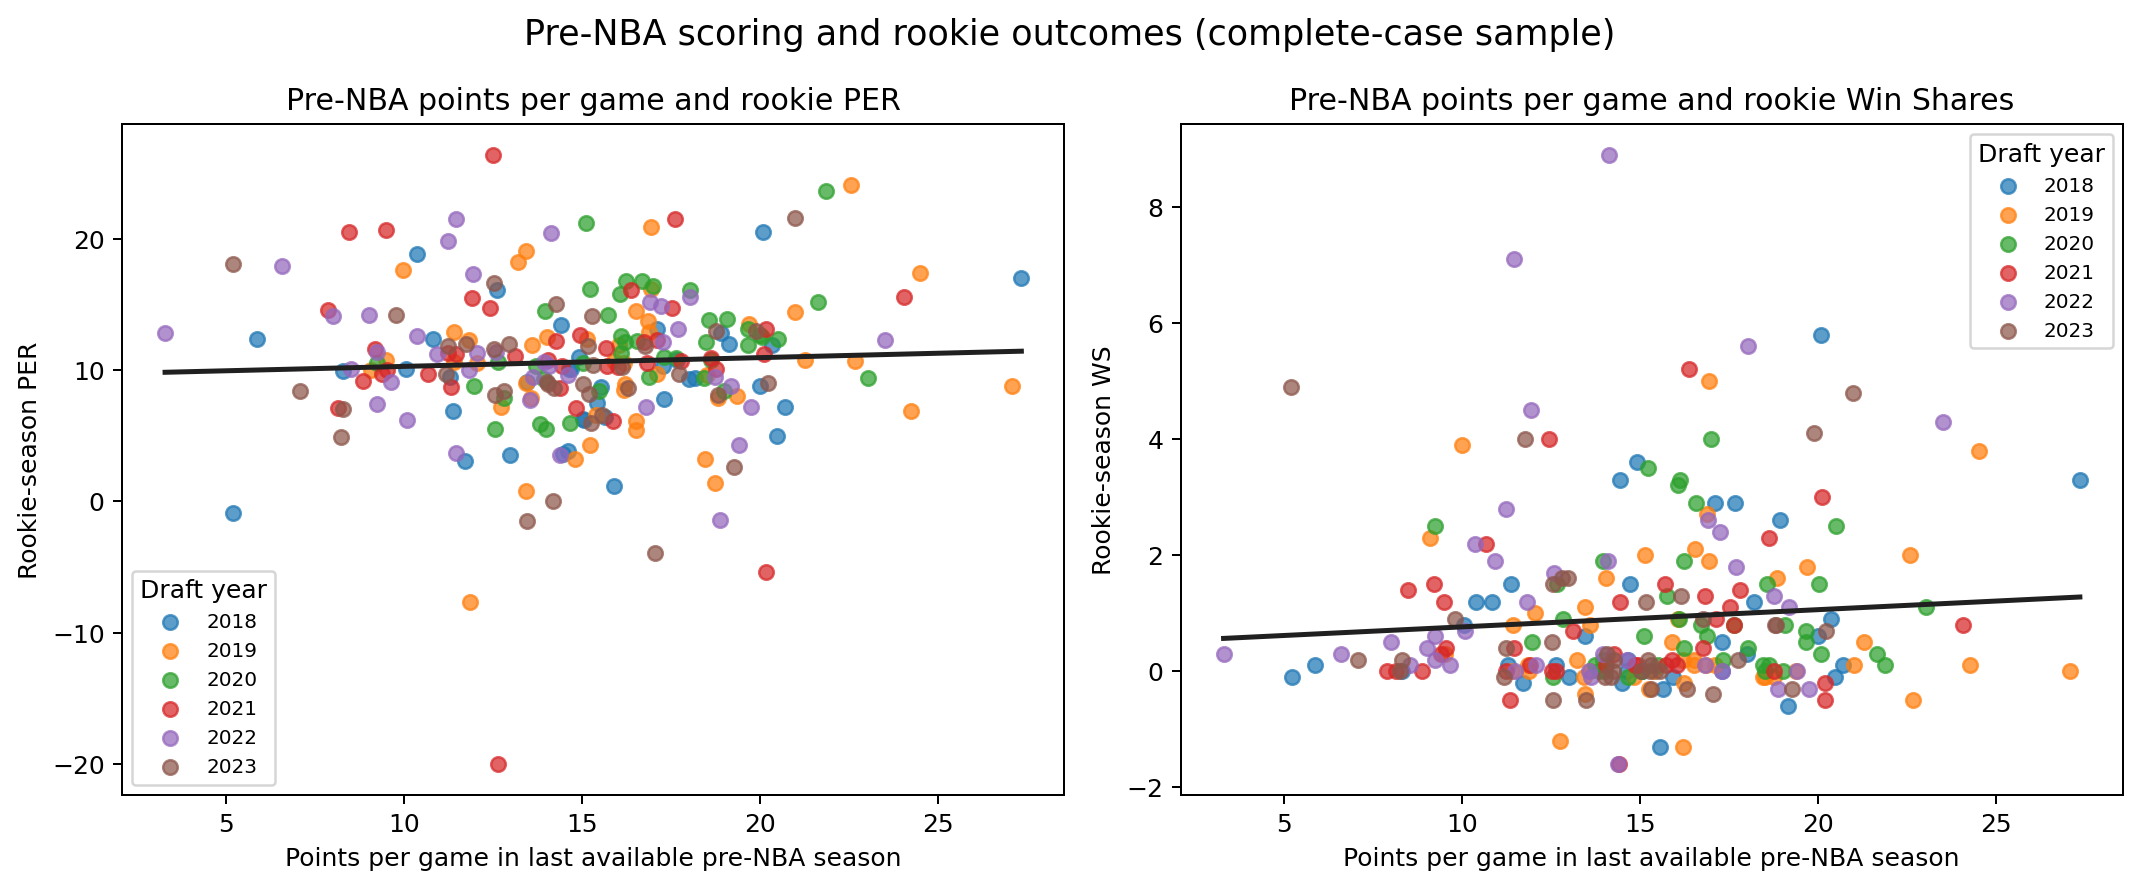

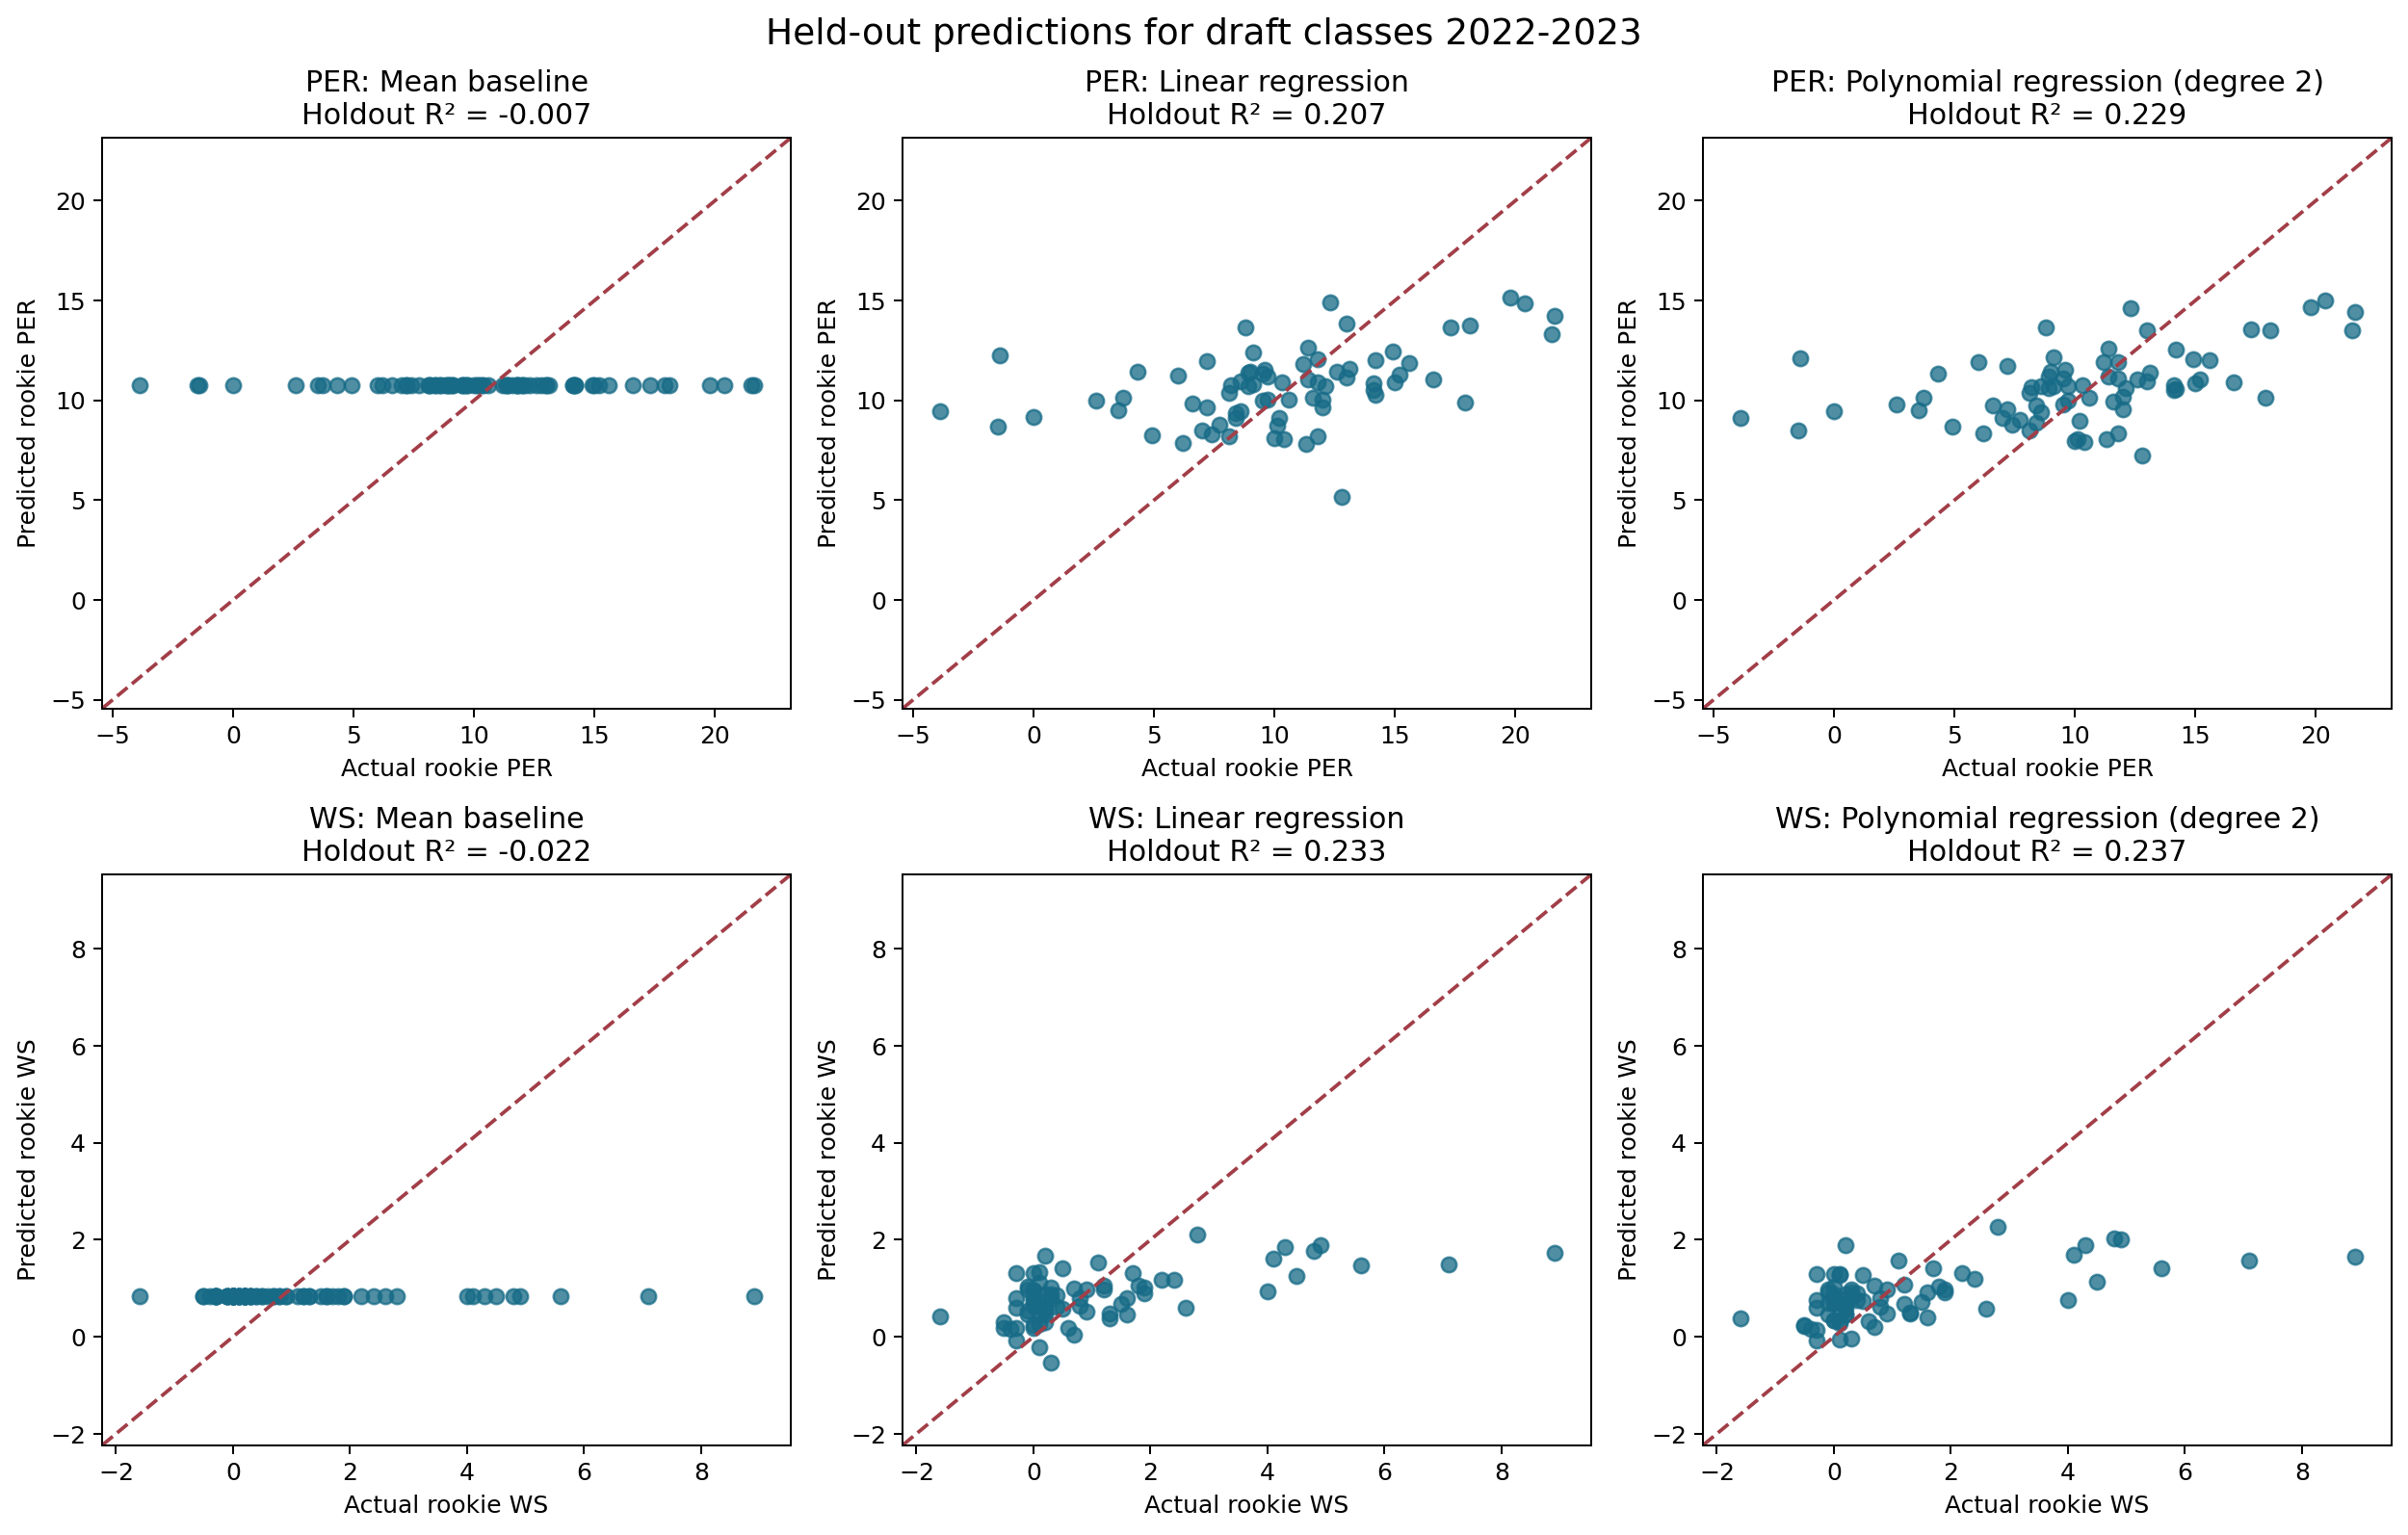

In [4]:
from nba_rookie_analysis import FIGURE_DIR
display(Image(filename=str(FIGURE_DIR / "college_scoring_vs_rookie_outcomes.png")))
display(Image(filename=str(FIGURE_DIR / "holdout_actual_vs_predicted.png")))

## 9. Results and interpretation on my visualizations

The first visualization compares each player’s latest available pre-NBA points per game with their rookie PER and Win Shares. Each dot represents one player, and the colors show the draft year. The trend lines rise slightly, but the dots are spread out, so points per game alone is not a strong predictor of either outcome. The correlations between points per game and rookie PER or Win Shares are close to zero.

The second visualization shows predictions for the 2022 and 2023 draft classes. The models learned from players drafted between 2018 and 2021. The dashed diagonal shows where a perfect prediction would fall. The linear and polynomial models are generally closer to that line than the average-value baseline, but many predictions still miss the actual results. The models often predict closer to the middle of the group and have more trouble with unusually high or low outcomes.

Polynomial regression had the lowest average error for both PER and Win Shares, but it only improved slightly over linear regression. Its R² was about 0.23 for each outcome. This means the model captured some of the differences among players in the holdout group, but most of those differences were still not explained by the features in this project. I would describe the predictions as modest, not reliable enough to judge an individual prospect.

The coefficient results suggest that field-goal percentage and age were most strongly associated with predicted PER in the linear model. Assists and turnovers had the largest coefficients for Win Shares. These results show associations in this sample; they do not prove that one statistic causes a player to succeed. Other factors, such as playing time, health, team situation, and the level of competition, may also affect rookie performance.

In [5]:
coefficient_tables = {}
for target in TARGETS:
    model = fitted_models[(target, "Linear regression")]
    coefficients = pd.Series(
        model.named_steps["regressor"].coef_,
        index=FEATURES,
        name=f"{target} standardized coefficient",
    ).sort_values(key=lambda values: values.abs(), ascending=False)
    coefficient_tables[target] = coefficients
    print(target)
    display(coefficients.to_frame().round(3))

print("Holdout players with the largest polynomial-model absolute errors:")
poly_errors = predictions[
    predictions["Model"] == "Polynomial regression (degree 2)"
].copy()
poly_errors["Absolute error"] = (poly_errors["Actual"] - poly_errors["Predicted"]).abs()
for target in TARGETS:
    print(target)
    display(
        poly_errors[poly_errors["Target"] == target]
        .nlargest(5, "Absolute error")[
            ["DraftYear", "Player", "Actual", "Predicted", "Absolute error"]
        ]
        .round(2)
    )

PER


,PER standardized coefficient
FG_pct,1.312
Age,-1.005
PTS_per_game,0.934
REB_per_game,0.866
TOV_per_game,-0.822
AST_per_game,0.637


WS


,WS standardized coefficient
AST_per_game,0.502
TOV_per_game,-0.421
FG_pct,0.387
Age,-0.224
PTS_per_game,0.203
REB_per_game,0.139


Holdout players with the largest polynomial-model absolute errors:
PER


,DraftYear,Player,Actual,Predicted,Absolute error
179,2022,Ryan Rollins,-1.4,12.10,13.50
214,2023,Maxwell Lewis,-3.9,9.12,13.02
196,2023,Jalen Hood-Schifino,-1.5,8.47,9.97
216,2023,Seth Lundy,0.0,9.44,9.44
164,2022,Walker Kessler,21.5,13.49,8.01


WS


,DraftYear,Player,Actual,Predicted,Absolute error
371,2022,Chet Holmgren,8.9,1.66,7.24
386,2022,Walker Kessler,7.1,1.57,5.53
377,2022,Jalen Williams,5.6,1.42,4.18
378,2022,Jalen Duren,4.5,1.13,3.37
411,2023,Cason Wallace,4.0,0.75,3.25


## 10. Limitations, ethics, and reflection

- **Missing pre-NBA data:** 110 players have no matched pre-NBA season record. International and other non-college players are especially likely to be missing. The 240-player sample is not representative of all 356 drafted players.
- **Survivorship and selection:** The project includes drafted players only. It cannot compare drafted prospects with undrafted players, and it does not explain who gets drafted.
- **Small sample:** There are 166 training players and 74 holdout players. A different draft-year split could produce different scores.
- **Outcome definitions:** PER and WS are imperfect summaries. WS is cumulative and affected by playing time and team performance; PER can be unstable for players with few minutes. The files do not provide consistent playing time for filtering.
- **Context and comparability:** The dataset combines pre-NBA environments and seasons. Similar statistics can mean different things across leagues, teams, roles, and levels of competition.
- **Model risk:** Polynomial regression only slightly outperforms linear regression here, and both leave most outcome variation unexplained. I would not use either alone for a real draft decision. Scouting, health, role, and development also matter.

## 11. Conclusion

On the 2022-2023 holdout, both regressions performed better than the training-mean baseline for PER and WS. Polynomial regression had the lowest MAE, but only by a small margin over linear regression. The supplied pre-NBA statistics contain some information about rookie outcomes, but they are not enough to predict an individual player's performance reliably.

The answer to the research question is **somewhat, but with substantial uncertainty**. A stronger follow-up would add verified final-season stats for international and semi-pro prospects, minutes played, competition level, and additional future draft classes.

## 12. Code and transparency

The reusable Python analysis is in [nba_rookie_analysis.py](nba_rookie_analysis.py). Run it from this folder with **python nba_rookie_analysis.py**. It reads the two CSVs in the draft-data folder, saves two figures and result tables in analysis_outputs, and prints coverage and model results.

Generative AI was used to help draft and debug the analysis code and project wording. Check the course's AI disclosure requirements and revise this statement if the instructor requires a specific format.

## References

Coates, D., & Oguntimein, B. (2010). The length and success of NBA careers: Does college production predict professional outcomes? *International Journal of Sport Finance, 5*(1), 4-26. https://doi.org/10.1177/155862351000500101

Moxley, J. H., & Towne, T. J. (2015). Predicting success in the National Basketball Association: Stability & potential. *Psychology of Sport and Exercise, 16*, 128-136. https://doi.org/10.1016/j.psychsport.2014.07.003

Basketball-Reference.com. (n.d.). *Glossary*. Retrieved October 3, 2026, from https://www.basketball-reference.com/about/glossary.html

JasonG7234. (n.d.). *NBA-Draft-Model* [Data set]. GitHub. Retrieved October 3, 2026, from https://github.com/JasonG7234/NBA-Draft-Model/tree/master/data

Basketball-Reference.com. (n.d.). *NBA 2018-19 advanced statistics*. Retrieved October 3, 2026, from https://www.basketball-reference.com/leagues/NBA_2019_advanced.html

Source URL columns in the CSVs link to the draft, rookie-stat, or pre-NBA record for each player. The supplied CSV copies were accessed October 3, 2026.